In [ ]:
!pip install networkx
!pip install matplotlib
!pip install seaborn


In [ ]:
# ===============================================================
# SECTION 2: IMPORT LIBRARIES
# ===============================================================

import pandas as pd
import numpy as np
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("\n[INFO] Libraries imported successfully.\n")



[INFO] Libraries imported successfully.



In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
print("\n[INFO] CSV Loaded:", list(uploaded.keys())[0])


Saving normalized_steam (1).csv to normalized_steam (1).csv

[INFO] CSV Loaded: normalized_steam (1).csv


In [ ]:
# ===============================================================
# SECTION 4: INITIAL INSPECTION
# ===============================================================

print("[DEBUG] DataFrame Shape:", df.shape)
print("\n[DEBUG] Column Names:", df.columns.tolist())

print("\n[DEBUG] First 5 Rows:")
print(df.head())

print("\n[DEBUG] Checking NA counts:")
print(df.isna().sum())


[DEBUG] DataFrame Shape: (27075, 18)

[DEBUG] Column Names: ['appid', 'name', 'release_date', 'english', 'developer', 'publisher', 'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners', 'price']

[DEBUG] First 5 Rows:
   appid                       name release_date  english         developer  \
0     10             Counter-Strike   2000-11-01        1             Valve   
1     20      Team Fortress Classic   1999-04-01        1             Valve   
2     30              Day of Defeat   2003-05-01        1             Valve   
3     40         Deathmatch Classic   2001-06-01        1             Valve   
4     50  Half-Life: Opposing Force   1999-11-01        1  Gearbox Software   

  publisher          platforms  required_age  \
0     Valve  windows;mac;linux             0   
1     Valve  windows;mac;linux             0   
2     Valve  windows;mac;linux             

In [ ]:
# ===============================================================
# SECTION 5: CLEAN GENRES, TAGS, CATEGORIES
# ===============================================================

def clean_to_list(x):
    """Convert semicolon-separated fields into list format."""
    if pd.isna(x):
        return []
    return [i.strip() for i in str(x).split(";") if len(i.strip()) > 0]

print("\n[INFO] Converting string fields to lists...")

df["genres_list"] = df["genres"].apply(clean_to_list)
df["categories_list"] = df["categories"].apply(clean_to_list)
df["tags_list"] = df["steamspy_tags"].apply(clean_to_list)

print("\n[DEBUG] Example transformed row:")
print(df[["genres", "genres_list"]].head(3))

# Remove games with no genre
before = df.shape[0]
df = df[df["genres_list"].apply(len) > 0]
after = df.shape[0]

print(f"\n[INFO] Removed {before - after} games without genres. Remaining: {after}")



[INFO] Converting string fields to lists...

[DEBUG] Example transformed row:
   genres genres_list
0  Action    [Action]
1  Action    [Action]
2  Action    [Action]

[INFO] Removed 0 games without genres. Remaining: 27075


In [ ]:
# ===============================================================
# SECTION 6: MULTI-HOT ENCODING FOR GENRES
# ===============================================================

mlb = MultiLabelBinarizer()
genre_matrix = pd.DataFrame(
    mlb.fit_transform(df["genres_list"]),
    columns=mlb.classes_,
    index=df["appid"]
)

print("\n[INFO] Multi-hot encoding completed.")
print("[DEBUG] Genre Matrix Shape:", genre_matrix.shape)

print("\n[DEBUG] Sample of Multi-hot Matrix:")
print(genre_matrix.head())



[INFO] Multi-hot encoding completed.
[DEBUG] Genre Matrix Shape: (27075, 29)

[DEBUG] Sample of Multi-hot Matrix:
       Accounting  Action  Adventure  Animation & Modeling  Audio Production  \
appid                                                                          
10              0       1          0                     0                 0   
20              0       1          0                     0                 0   
30              0       1          0                     0                 0   
40              0       1          0                     0                 0   
50              0       1          0                     0                 0   

       Casual  Design & Illustration  Documentary  Early Access  Education  \
appid                                                                        
10          0                      0            0             0          0   
20          0                      0            0             0          0   
30          

In [ ]:
# ===============================================================
# SECTION 7: GENRE CO-OCCURRENCE MATRIX
# ===============================================================

print("\n[INFO] Building genre co-occurrence matrix...")

genres = mlb.classes_
co_matrix = pd.DataFrame(0, index=genres, columns=genres)

for appid, row in genre_matrix.iterrows():
    active_genres = row[row == 1].index.tolist()
    pairs = itertools.combinations(active_genres, 2)
    for g1, g2 in pairs:
        co_matrix.loc[g1, g2] += 1
        co_matrix.loc[g2, g1] += 1

print("\n[INFO] Co-occurrence matrix built.")
print("\n[DEBUG] Sample:")
print(co_matrix.iloc[:10, :10])



[INFO] Building genre co-occurrence matrix...

[INFO] Co-occurrence matrix built.

[DEBUG] Sample:
                       Accounting  Action  Adventure  Animation & Modeling  \
Accounting                      0       0          1                     3   
Action                          0       0       4526                     0   
Adventure                       1    4526          0                     1   
Animation & Modeling            3       0          1                     0   
Audio Production                3       0          0                     7   
Casual                          4    3399       3564                     8   
Design & Illustration           4       0          1                    54   
Documentary                     1       0          0                     0   
Early Access                    1    1714       1008                    21   
Education                       4       0          1                    25   

                       Audio Production  

In [ ]:
print("\n[INFO] Computing normalized co-occurrence matrices...")

# --- Precompute genre counts ---
genre_counts = genre_matrix.sum(axis=0)
total_games = len(df)

print("[DEBUG] Total games:", total_games)
print("[DEBUG] Genre counts (first 10):")
print(genre_counts.head(10))


# ===============================================================
# 1. JACCARD SIMILARITY MATRIX
# ===============================================================

jaccard = pd.DataFrame(0.0, index=genres, columns=genres)

for g1 in genres:
    for g2 in genres:
        inter = co_matrix.loc[g1, g2]        # intersection
        union = genre_counts[g1] + genre_counts[g2] - inter

        if union > 0:
            jaccard.loc[g1, g2] = inter / union
        else:
            jaccard.loc[g1, g2] = 0.0

print("\n[INFO] Jaccard similarity computed.")
print("\n[DEBUG] Jaccard Sample (first 10 rows):")
print(jaccard.iloc[:10, :10])


# ===============================================================
# 2. COSINE SIMILARITY MATRIX
# ===============================================================

from sklearn.metrics.pairwise import cosine_similarity

cosine = pd.DataFrame(
    cosine_similarity(genre_matrix.T),
    index=genres,
    columns=genres,
)

print("\n[INFO] Cosine similarity computed.")
print("\n[DEBUG] Cosine Sample (first 10 rows):")
print(cosine.iloc[:10, :10])


# ===============================================================
# 3. PMI (Pointwise Mutual Information)
# ===============================================================

pmi = pd.DataFrame(0.0, index=genres, columns=genres)

for g1 in genres:
    for g2 in genres:
        pA = genre_counts[g1] / total_games
        pB = genre_counts[g2] / total_games
        pAB = co_matrix.loc[g1, g2] / total_games

        if pAB > 0:
            pmi.loc[g1, g2] = np.log(pAB / (pA * pB))
        else:
            pmi.loc[g1, g2] = 0.0

print("\n[INFO] PMI matrix computed.")
print("\n[DEBUG] PMI Sample (first 10 rows):")
print(pmi.iloc[:10, :10])


print("\n[INFO] All normalization matrices computed successfully.")



[INFO] Computing normalized co-occurrence matrices...
[DEBUG] Total games: 27075
[DEBUG] Genre counts (first 10):
Accounting                   6
Action                   11903
Adventure                10032
Animation & Modeling        79
Audio Production            29
Casual                   10210
Design & Illustration       87
Documentary                  1
Early Access              2954
Education                   51
dtype: int64

[INFO] Jaccard similarity computed.

[DEBUG] Jaccard Sample (first 10 rows):
                       Accounting    Action  Adventure  Animation & Modeling  \
Accounting               0.000000  0.000000   0.000100              0.036585   
Action                   0.000000  0.000000   0.259980              0.000000   
Adventure                0.000100  0.259980   0.000000              0.000099   
Animation & Modeling     0.036585  0.000000   0.000099              0.000000   
Audio Production         0.093750  0.000000   0.000000              0.069307   
Casu


[INFO] Extracting Top 20 Genre Pairs using Jaccard Similarity...

[DEBUG] Top 20 Genre Pairs (Jaccard Similarity):
                   Genre A                Genre B   Jaccard
191            Documentary               Tutorial  1.000000
83    Animation & Modeling  Design & Illustration  0.482143
284                   Gore                Violent  0.479100
227              Education      Software Training  0.464286
318                 Nudity         Sexual Content  0.431373
39                  Action                  Indie  0.414751
137                 Casual                  Indie  0.368448
65               Adventure                  Indie  0.349198
102   Animation & Modeling              Utilities  0.308140
171  Design & Illustration              Utilities  0.294444
28                  Action              Adventure  0.259980
384      Software Training         Web Publishing  0.255319
155  Design & Illustration              Education  0.243243
86    Animation & Modeling              Educ

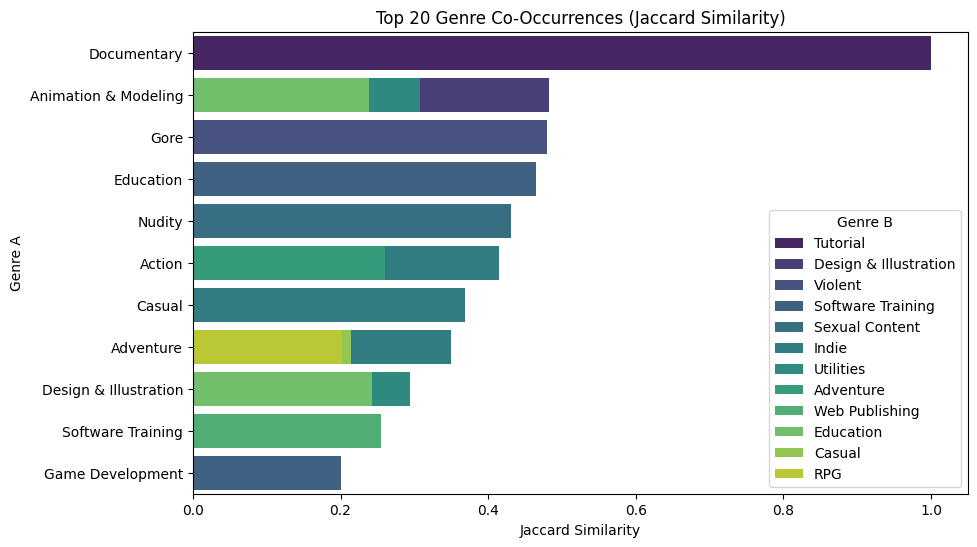


[INFO] Top 20 genre pairs extracted and visualized.


In [ ]:
# ===============================================================
# SECTION 7C: TOP 20 GENRE PAIRS (Jaccard Similarity)
# ===============================================================

print("\n[INFO] Extracting Top 20 Genre Pairs using Jaccard Similarity...")

# Flatten the Jaccard matrix into pair list
pairs = []

for g1 in genres:
    for g2 in genres:
        if g1 < g2:  # avoid duplicates and self-pairs
            sim = jaccard.loc[g1, g2]
            pairs.append((g1, g2, sim))

# Convert to DataFrame
pairs_df = pd.DataFrame(pairs, columns=["Genre A", "Genre B", "Jaccard"])

# Sort by Jaccard descending
pairs_df = pairs_df.sort_values("Jaccard", ascending=False)

# Show top 20
top20 = pairs_df.head(20)

print("\n[DEBUG] Top 20 Genre Pairs (Jaccard Similarity):")
print(top20)

# Optional: Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top20,
    x="Jaccard",
    y="Genre A",
    hue="Genre B",
    dodge=False,
    palette="viridis"
)
plt.title("Top 20 Genre Co-Occurrences (Jaccard Similarity)")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Genre A")
plt.legend(title="Genre B")
plt.show()

print("\n[INFO] Top 20 genre pairs extracted and visualized.")


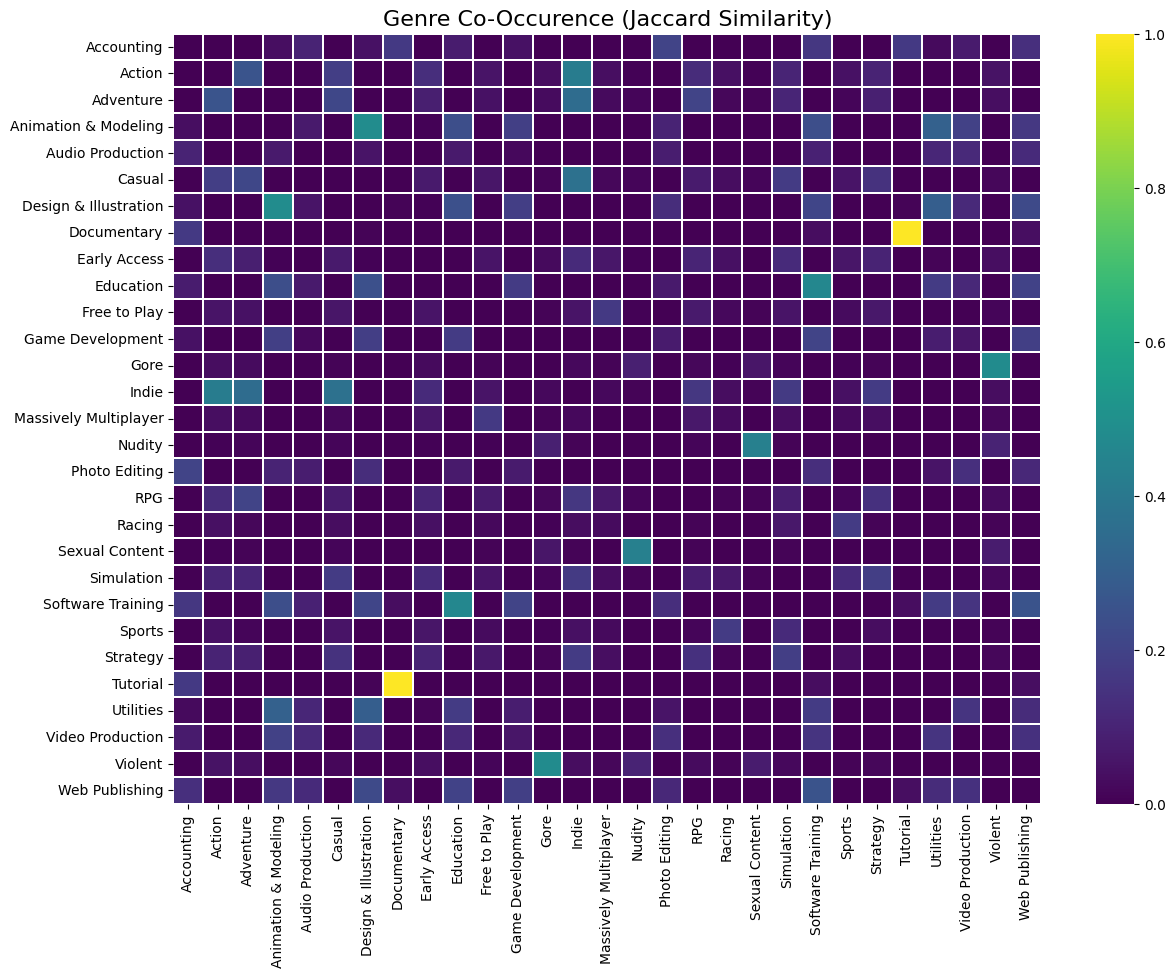


[INFO] Jaccard heatmap displayed.


In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(jaccard, cmap="viridis", linewidths=0.3)
plt.title("Genre Co-Occurence (Jaccard Similarity)", fontsize=16)
plt.show()

print("\n[INFO] Jaccard heatmap displayed.")



[INFO] Building NetworkX graph using Jaccard similarity...
[DEBUG] Nodes: 29
[DEBUG] Edges: 102


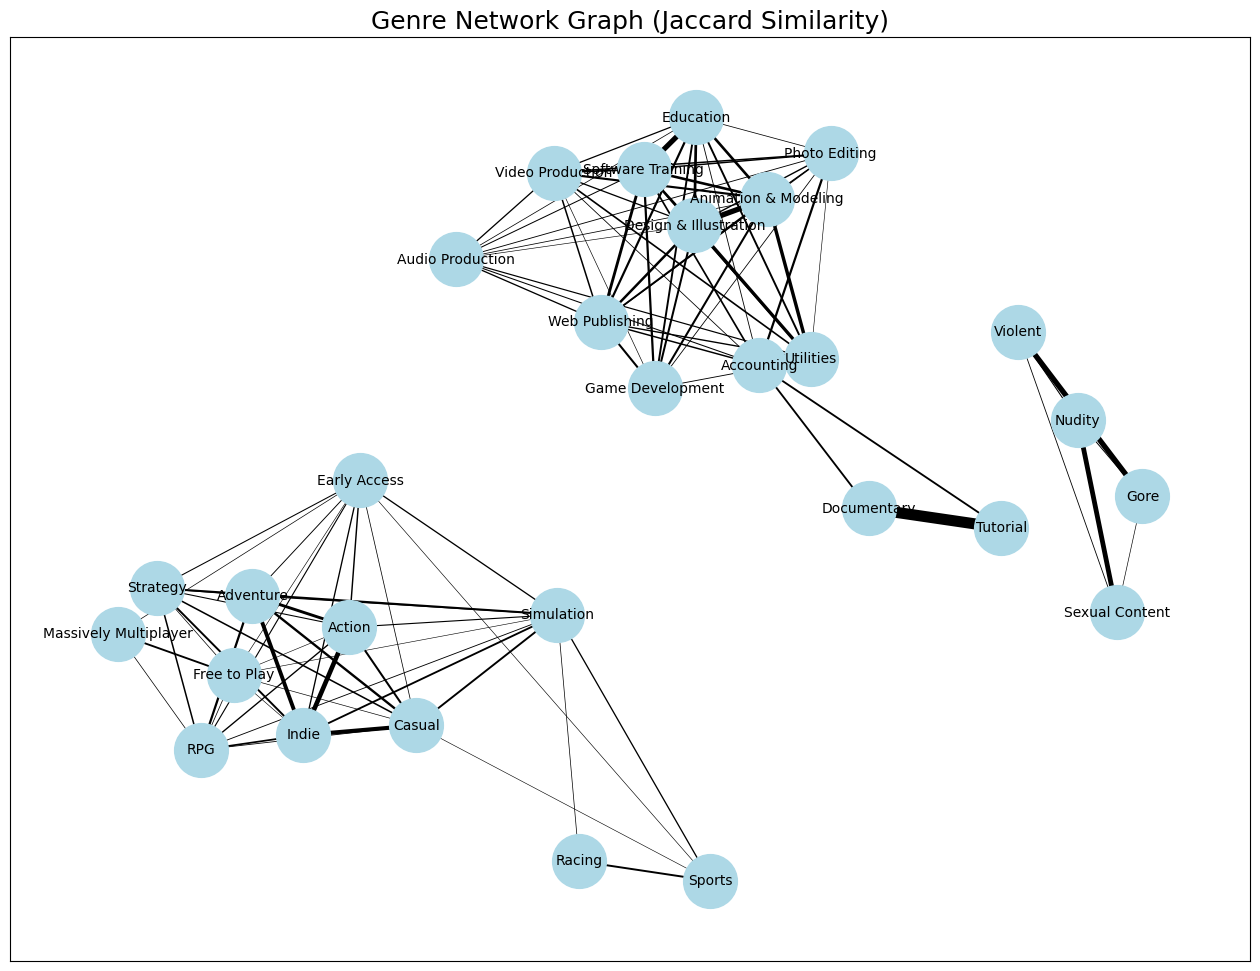


[INFO] Network graph (Jaccard) displayed.


In [ ]:
print("\n[INFO] Building NetworkX graph using Jaccard similarity...")

G = nx.Graph()

# Threshold small values to reduce noise
threshold = 0.05  # adjustable

for g1 in genres:
    for g2 in genres:
        weight = jaccard.loc[g1, g2]
        if weight > threshold and g1 != g2:
            G.add_edge(g1, g2, weight=weight)

print("[DEBUG] Nodes:", len(G.nodes()))
print("[DEBUG] Edges:", len(G.edges()))

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.9, iterations=80)

edge_weights = [d['weight'] * 8 for (_,_,d) in G.edges(data=True)]
nx.draw_networkx(
    G, pos, with_labels=True, width=edge_weights,
    node_size=1500, font_size=10, node_color='lightblue'
)

plt.title("Genre Network Graph (Jaccard Similarity)", fontsize=18)
plt.show()

print("\n[INFO] Network graph (Jaccard) displayed.")


In [ ]:
# ===============================================================
# SECTION 11: BUILD TECHNICAL FEATURE MATRIX
# ===============================================================

print("\n[INFO] Building technical feature matrix...")

technical_features = [
    "Single-player", "Multi-player", "Co-op", "Online Multi-Player",
    "Steam Achievements", "Steam Cloud", "Full controller support",
    "Valve Anti-Cheat enabled", "Stats", "Steam Trading Cards"
]

# Build empty matrix
tech_matrix = pd.DataFrame(0, index=df["appid"], columns=technical_features)

for idx, row in df.iterrows():
    for feature in technical_features:
        tech_matrix.loc[row["appid"], feature] = 1 if feature in row["categories_list"] else 0

print("[DEBUG] Technical Matrix Shape:", tech_matrix.shape)
print(tech_matrix.head())



[INFO] Building technical feature matrix...
[DEBUG] Technical Matrix Shape: (27075, 10)
       Single-player  Multi-player  Co-op  Online Multi-Player  \
appid                                                            
10                 0             1      0                    1   
20                 0             1      0                    1   
30                 0             1      0                    0   
40                 0             1      0                    1   
50                 1             1      0                    0   

       Steam Achievements  Steam Cloud  Full controller support  \
appid                                                             
10                      0            0                        0   
20                      0            0                        0   
30                      0            0                        0   
40                      0            0                        0   
50                      0            0        

In [ ]:
# ===============================================================
# SECTION 12: KMEANS CLUSTERING
# ===============================================================

print("\n[INFO] Running KMeans clustering...")

scaler = StandardScaler()
scaled = scaler.fit_transform(tech_matrix)

kmeans = KMeans(n_clusters=4, random_state=42)
df["tech_cluster"] = kmeans.fit_predict(scaled)

print("\n[DEBUG] Cluster Distribution:")
print(df["tech_cluster"].value_counts())



[INFO] Running KMeans clustering...

[DEBUG] Cluster Distribution:
tech_cluster
1    15074
2     6656
0     3935
3     1410
Name: count, dtype: int64


In [ ]:
# ===============================================================
# SECTION 13: GENRE → TECHNICAL CLUSTER MAPPING
# ===============================================================

genre_cluster_map = {}

for g in genres:
    games_with_genre = df[df["genres_list"].apply(lambda x: g in x)]
    cluster_counts = games_with_genre["tech_cluster"].value_counts()
    genre_cluster_map[g] = cluster_counts.to_dict()

genre_cluster_map_df = pd.DataFrame(genre_cluster_map).fillna(0).T

print("\n[INFO] Genre → Technical Cluster mapping:")
print(genre_cluster_map_df)



[INFO] Genre → Technical Cluster mapping:
                             1      3       2       0
Accounting                 4.0    2.0     0.0     0.0
Action                  6117.0  850.0  3167.0  1769.0
Adventure               5455.0  213.0  2691.0  1673.0
Animation & Modeling      23.0   55.0     0.0     1.0
Audio Production          12.0   17.0     0.0     0.0
Casual                  6220.0  321.0  2193.0  1476.0
Design & Illustration     19.0   65.0     1.0     2.0
Documentary                1.0    0.0     0.0     0.0
Early Access            1908.0  436.0   404.0   206.0
Education                 15.0   35.0     1.0     0.0
Free to Play            1004.0  429.0   143.0   128.0
Game Development           4.0   13.0     0.0     0.0
Gore                     333.0   30.0   101.0    73.0
Indie                  10349.0  822.0  5097.0  3153.0
Massively Multiplayer    202.0  421.0    30.0    70.0
Nudity                   141.0    5.0    56.0    64.0
Photo Editing              3.0    7.0  

In [ ]:
# Map cluster numbers to labels
cluster_labels = {
    1: "Offline / Single-Player",
    3: "Online / Co-op Multiplayer",
    2: "Mixed Feature-Rich Games",
    0: "Enhanced / Controller-Supported"
}

# Rename columns using the labels
genre_cluster_named = genre_cluster_map_df.rename(columns=cluster_labels)

print("\n[INFO] Cluster names applied:")
print(genre_cluster_named.head())



[INFO] Cluster names applied:
                      Offline / Single-Player  Online / Co-op Multiplayer  \
Accounting                                4.0                         2.0   
Action                                 6117.0                       850.0   
Adventure                              5455.0                       213.0   
Animation & Modeling                     23.0                        55.0   
Audio Production                         12.0                        17.0   

                      Mixed Feature-Rich Games  \
Accounting                                 0.0   
Action                                  3167.0   
Adventure                               2691.0   
Animation & Modeling                       0.0   
Audio Production                           0.0   

                      Enhanced / Controller-Supported  
Accounting                                        0.0  
Action                                         1769.0  
Adventure                            

In [ ]:
# Normalized version (row-wise)
genre_cluster_norm = genre_cluster_named.div(genre_cluster_named.sum(axis=1), axis=0)


In [ ]:
subset = genre_cluster_named.loc[top_genres]


In [ ]:
# Sort by total games per genre
top_genres = genre_cluster_named.sum(axis=1).sort_values(ascending=False).head(15).index
subset = genre_cluster_norm.loc[top_genres]



[INFO] Generating improved stacked bar chart...


<Figure size 1400x900 with 0 Axes>

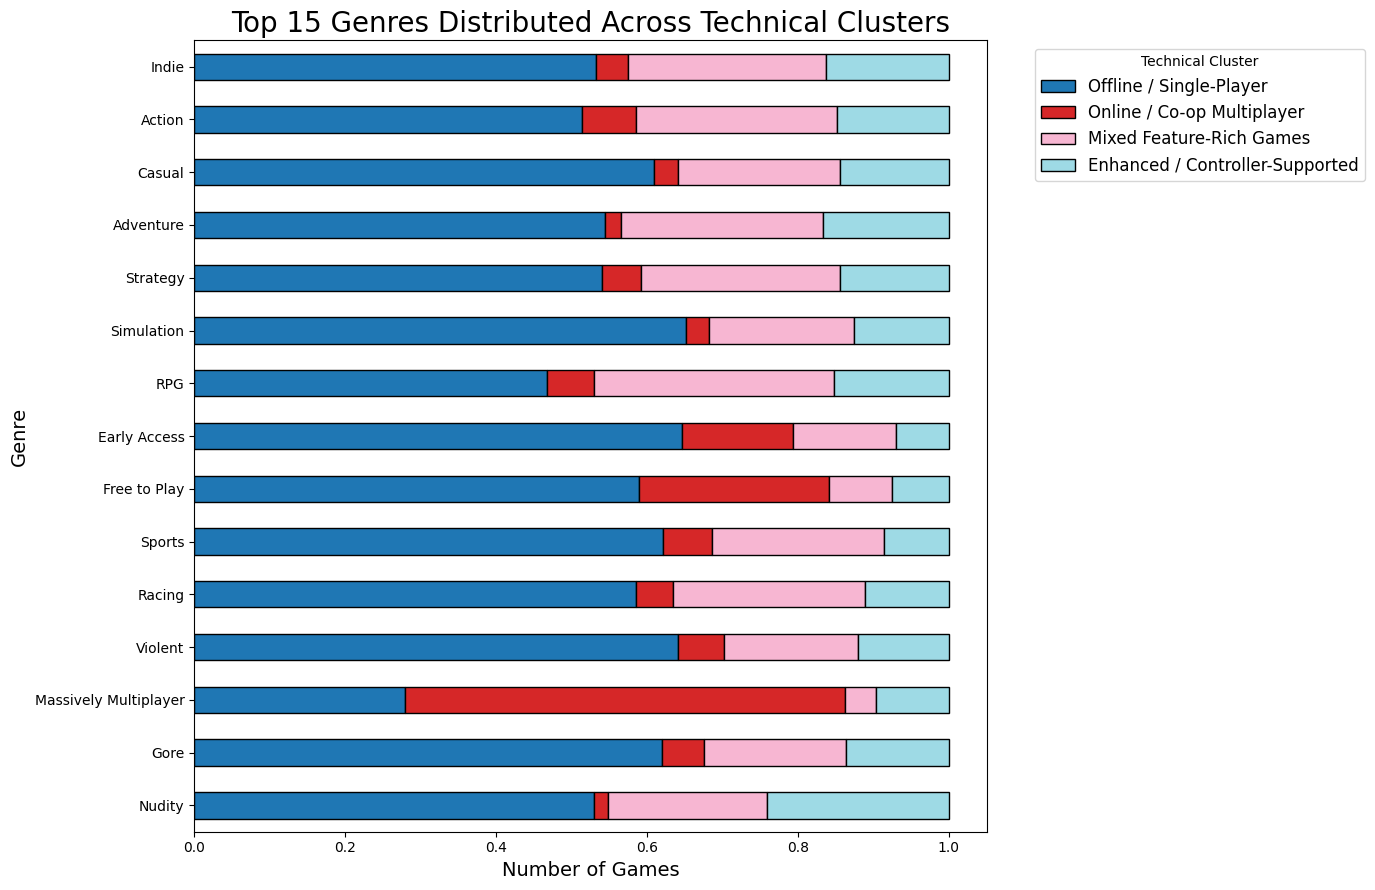


[INFO] Improved stacked bar chart displayed.


In [ ]:
# ===============================================================
# VISUALIZATION: STACKED BAR CHART WITH LABELED CLUSTERS
# ===============================================================

print("\n[INFO] Generating improved stacked bar chart...")

plt.figure(figsize=(14, 9))

subset.plot(
    kind='barh',
    stacked=True,
    figsize=(14, 9),
    colormap='tab20',
    edgecolor='black'
)

plt.title("Top 15 Genres Distributed Across Technical Clusters", fontsize=20)
plt.xlabel("Number of Games", fontsize=14)
plt.ylabel("Genre", fontsize=14)

plt.legend(
    title="Technical Cluster",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=12
)

plt.gca().invert_yaxis()  # so highest is at top
plt.tight_layout()
plt.show()

print("\n[INFO] Improved stacked bar chart displayed.")


In [ ]:
# ===============================================================
# SECTION 14: SUMMARY
# ===============================================================

print("\n==================== SUMMARY ====================\n")

print("1. GENRE NETWORK:")
print("- Built co-occurrence matrix")
print("- Constructed NetworkX graph")
print("- Calculated centrality scores")

print("\n2. TECHNICAL CLUSTERS:")
print("- Extracted categories (e.g., multiplayer, VAC, etc.)")
print("- Ran KMeans clustering (4 clusters)")
print("- Mapped genres to technical clusters")

print("\n3. VISUALIZATIONS GENERATED:")
print("- Heatmap of genre co-occurrence")
print("- Network graph of genre relationships")

print("\n[INFO] Notebook Execution Complete!")



==================== SUMMARY ====================

1. GENRE NETWORK:
- Built co-occurrence matrix
- Constructed NetworkX graph
- Calculated centrality scores

2. TECHNICAL CLUSTERS:
- Extracted categories (e.g., multiplayer, VAC, etc.)
- Ran KMeans clustering (4 clusters)
- Mapped genres to technical clusters

3. VISUALIZATIONS GENERATED:
- Heatmap of genre co-occurrence
- Network graph of genre relationships

[INFO] Notebook Execution Complete!
